<a href="https://colab.research.google.com/github/CodeAndBleep/NLP-IMDB/blob/The-Beginning/Dolorosa_basic_nlp_imdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic Natural Language Processing (NLP) with IMDB Reviews

This notebook introduces a **basic NLP workflow** using the **IMDB movie reviews** dataset from `tensorflow.keras.datasets`.

## What students will learn
- What text data looks like in machine learning
- How text is converted into numerical form
- How to train a simple text classification model
- How to evaluate the model
- How to test predictions on sample reviews

## Why this dataset?
The IMDB dataset is a beginner-friendly dataset for **sentiment analysis**.

Each movie review is labeled as:
- **0 = negative review**
- **1 = positive review**

Because the dataset is included in TensorFlow, students do not need to download anything manually.


## 1. Import the libraries

We use:
- **TensorFlow / Keras** for building the model
- **NumPy** for numerical work
- **Matplotlib** for plotting training results


In [29]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load the IMDB dataset

We will keep only the **10,000 most common words** in the dataset.

This makes the problem more manageable for beginners and helps reduce the size of the input space.


In [30]:
vocab_size = 10000

imdb = tf.keras.datasets.imdb
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Number of training reviews:", len(x_train))
print("Number of test reviews:", len(x_test))
print("Example encoded review:", x_train[0][:20])
print("Example label:", y_train[0])

Number of training reviews: 25000
Number of test reviews: 25000
Example encoded review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Example label: 1


## 3. Understand the data

Unlike image datasets, the reviews are not stored as pixels.

Instead, each review is stored as a **sequence of integers**.  
Each integer represents a word in the vocabulary.

For example:
- `1`, `14`, `20`, etc. are not the words themselves
- they are **word indices**


In [31]:
print("Length of first training review:", len(x_train[0]))
print("Length of second training review:", len(x_train[1]))
print("First 30 tokens of first review:", x_train[0][:30])

Length of first training review: 218
Length of second training review: 189
First 30 tokens of first review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480]


## 4. Convert word indices back to text

To make the data more understandable, we will decode one review back into readable words.

TensorFlow provides a word index dictionary for the IMDB dataset.


In [32]:
word_index = imdb.get_word_index()

# Reserve special tokens
word_index = {k: (v + 3) for k, v in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2
word_index["<UNUSED>"] = 3

reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(text_ids):
    return " ".join(reverse_word_index.get(i, "?") for i in text_ids)

print(decode_review(x_train[0][:100]))

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was


## 5. Preprocess the text

Machine learning models usually require inputs of the **same length**.

However, reviews have different lengths.

To solve this, we use **padding**:
- shorter reviews are extended with zeros
- longer reviews are cut to a fixed length

This makes the input shape consistent for the model.


In [33]:
max_length = 200

x_train = tf.keras.preprocessing.sequence.pad_sequences(
    x_train,
    value=word_index["<PAD>"],
    padding="post",
    maxlen=max_length
)

x_test = tf.keras.preprocessing.sequence.pad_sequences(
    x_test,
    value=word_index["<PAD>"],
    padding="post",
    maxlen=max_length
)

print("Shape of training data after padding:", x_train.shape)
print("Shape of test data after padding:", x_test.shape)
print("First padded review length:", len(x_train[0]))

Shape of training data after padding: (25000, 200)
Shape of test data after padding: (25000, 200)
First padded review length: 200


## 6. Build a simple NLP model

We will use a simple neural network for text classification.

### Model structure
- `Embedding`: converts word indices into dense vectors
- `GlobalAveragePooling1D`: summarizes the sequence into one vector
- `Dense`: learns patterns for classification
- Final `Dense`: predicts whether the review is positive or negative

### Why use an embedding layer?
Words cannot be used directly as raw integers.  
The embedding layer learns a more useful numerical representation of words.


In [34]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 32, input_length=max_length), # creates 10000 x 16 "array" of numbers
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Compile the model

Since this is a **binary classification** task:
- the output is either **positive** or **negative**
- we use `binary_crossentropy` as the loss
- we use `accuracy` as a simple evaluation metric


In [35]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 8. Create a validation set

Before training, we separate part of the training data for validation.

This helps us check how well the model performs on unseen data during training.


In [36]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

print("Partial training set shape:", partial_x_train.shape)
print("Validation set shape:", x_val.shape)

Partial training set shape: (15000, 200)
Validation set shape: (10000, 200)


## 9. Train the model

The model will learn patterns from the review texts and their sentiment labels.


In [37]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=15,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.6109 - loss: 0.6862 - val_accuracy: 0.6701 - val_loss: 0.6755
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7155 - loss: 0.6566 - val_accuracy: 0.7461 - val_loss: 0.6359
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7562 - loss: 0.6050 - val_accuracy: 0.7776 - val_loss: 0.5793
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8005 - loss: 0.5381 - val_accuracy: 0.8057 - val_loss: 0.5131
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8315 - loss: 0.4704 - val_accuracy: 0.8278 - val_loss: 0.4556
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.8495 - loss: 0.4134 - val_accuracy: 0.8281 - val_loss: 0.4151
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.8643 - loss: 0.3698 - val_accuracy: 0.8499 - val_loss: 0.3784
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8745 - loss: 0.3359 - val_accuracy: 0.8532 - v

## 10. Visualize training performance

These plots help us see:
- whether accuracy improves
- whether loss decreases
- whether the model may be overfitting


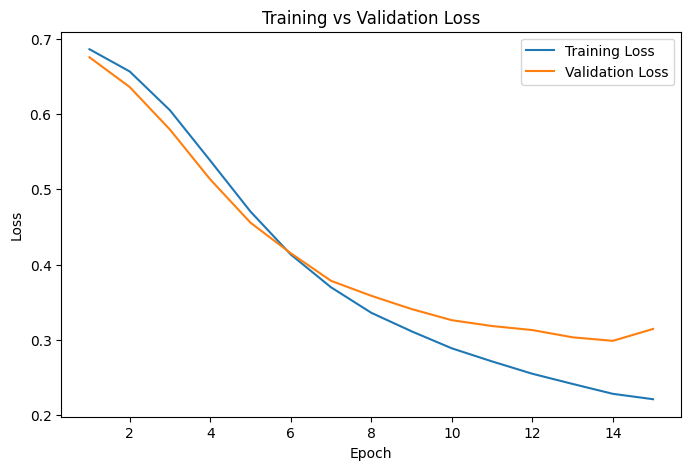

In [38]:
history_dict = history.history

acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
loss = history_dict["loss"]
val_loss = history_dict["val_loss"]

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

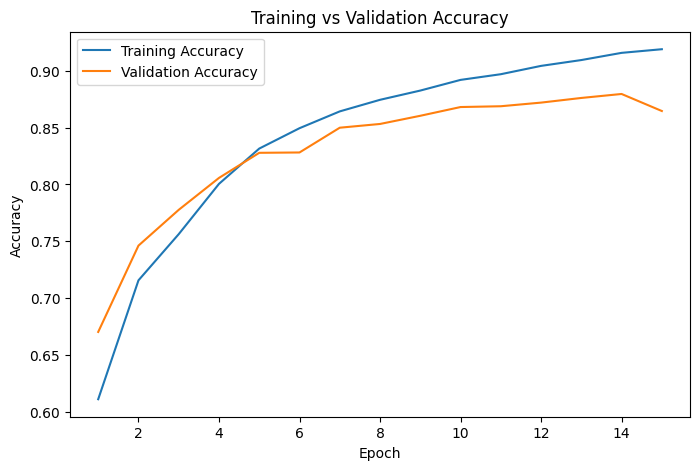

In [39]:
plt.figure(figsize=(8,5))
plt.plot(epochs, acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

## 11. Evaluate the model on the test set

The test set contains reviews the model has **never seen before**.

This gives us a better estimate of real performance.


In [40]:
results = model.evaluate(x_test, y_test, verbose=2)

print("Test loss:", results[0])
print("Test accuracy:", results[1])

782/782 - 2s - 2ms/step - accuracy: 0.8576 - loss: 0.3229
Test loss: 0.3229183852672577
Test accuracy: 0.8575999736785889


## 12. Make predictions

The model outputs a value between **0 and 1**:
- closer to **0** means more negative
- closer to **1** means more positive


In [41]:
predictions = model.predict(x_test[:5])

for i, pred in enumerate(predictions):
    predicted_label = 1 if pred[0] >= 0.5 else 0
    actual_label = y_test[i]
    print(f"Review {i}")
    print("Predicted score:", float(pred[0]))
    print("Predicted label:", "positive" if predicted_label == 1 else "negative")
    print("Actual label:", "positive" if actual_label == 1 else "negative")
    print("-" * 50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Review 0
Predicted score: 0.40351277589797974
Predicted label: negative
Actual label: negative
--------------------------------------------------
Review 1
Predicted score: 0.9946237802505493
Predicted label: positive
Actual label: positive
--------------------------------------------------
Review 2
Predicted score: 0.6737865805625916
Predicted label: positive
Actual label: positive
--------------------------------------------------
Review 3
Predicted score: 0.5869079828262329
Predicted label: positive
Actual label: negative
--------------------------------------------------
Review 4
Predicted score: 0.9860969185829163
Predicted label: positive
Actual label: positive
--------------------------------------------------


## 13. Decode and inspect a review

It is useful to compare:
- the actual text
- the true label
- the predicted label

This helps students see how NLP is connected to language understanding.


In [42]:
review_index = 0
decoded_text = decode_review(x_test[review_index])

pred_score = model.predict(x_test[review_index:review_index+1])[0][0]
pred_label = "positive" if pred_score >= 0.5 else "negative"
true_label = "positive" if y_test[review_index] == 1 else "negative"

print("True label:", true_label)
print("Predicted label:", pred_label)
print("Predicted score:", float(pred_score))
print("\nReview text:\n")
print(decoded_text[:2000])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
True label: negative
Predicted label: negative
Predicted score: 0.40351274609565735

Review text:

<START> please give this one a miss br br <UNK> <UNK> and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite <UNK> so all you madison fans give this a miss <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD

## 14. Guide questions / activity

Answer these after running the notebook:

1. What do the numbers in the review sequences represent?
2. Why do we need padding for text data?
3. What is the role of the embedding layer?
4. What test accuracy did your model achieve?
5. Why might the model misclassify some reviews?

### Simple modification task
Try changing **one** of the following:
- increase epochs from `10` to `15`
- change the embedding size from `16` to `32`
- change `max_length` from `256` to `200`

Then answer:
- Did the accuracy improve or decrease?
- Why do you think that happened?


## 15. Conclusion

In this notebook, you completed a simple NLP pipeline:

1. loaded a text dataset  
2. examined encoded reviews  
3. decoded text for interpretation  
4. padded sequences to a fixed length  
5. trained a sentiment classification model  
6. evaluated the model  
7. interpreted predictions  

This is a basic example of how NLP systems process text and classify sentiment using deep learning.
